In [ ]:
# [실습] 이진 분류 모델링 1: 로지스틱 회귀


# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 전처리와 평가를 위한 sklearn 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler


# 파이토치 라이브러리
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
### ⭐한 개의 함수는 한개의 기능만 하게 생성하기~! (아래는 데이터셋과 데이터로더의 두개의 기능을 하나로 묶어서 잘못됨)

def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

In [ ]:
### 신경망 학습 함수 :
# ⭐어디서 학습할지(device), 데이터(DataLoader) -> 모델(신경망) -> 손실함수(loss-fn) -> 업데이트(옵티마이저)

def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0 # 전체 오차


    model.train() # ⭐학습하기 전에 반드시 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩, 배치사이즈 만큼씩 데이터 꺼내줌(학습데이터, 학습데이터 레이블)
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(순전파)
        pred = model(x) # Sigmoid (예측값)
        loss = loss_fn(pred, y) # 오차를 구하는 함수, BCE(분류모델의 오차)
        tr_loss += loss # 전체 오차에 누적


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값(W) 초기화 -> 다음 배치 계산을 위해


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

In [ ]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정 (이걸 해야 역전파 안함)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x) # 예측값 추출
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [7]:
# 데이터 로딩
path = 'https://bit.ly/titanic_simple_csv'
data = pd.read_csv(path)
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [8]:
# 데이터 로딩
path = 'https://bit.ly/titanic_simple_csv'
data = pd.read_csv(path)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [9]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']
x = data.loc[:, features]
y = data.loc[:, target]

In [10]:
x = pd.get_dummies(x, columns = ['Sex'], drop_first = True)
x.head()

,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


In [ ]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val를 넘파이 배열로 변환
y_train = y_train.values    # ndarray 반환
y_val = y_val.values        # ndarray 반환

In [12]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val를 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values

In [13]:
# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [14]:
#첫 번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f'Shape of x [rows, columns]: {x.shape}')
    print(f'Shape of y: {y.shape} {y.dtype}')
    break

Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


In [15]:
n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential( nn.Linear(n_feature, 1),
                nn.Sigmoid()
                ).to(device)

In [ ]:
loss_fn = nn.BCELoss()  # 이진분류의 오차 BCE
optimizer = Adam(model.parameters(), lr=0.01)   # 학습률이 너무 작으면 로컬미니멈에 갇히고, 너무 크면 발산(다침)되서 수렴이 안됨

In [17]:
# 에폭 : "전체 데이터"를 한번 학습하는 것을 1 에폭이라고 한다.

epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 0.685056, val loss : 0.663534
Epoch 2, train loss : 0.667606, val loss : 0.643790
Epoch 3, train loss : 0.651499, val loss : 0.627020
Epoch 4, train loss : 0.639906, val loss : 0.613134
Epoch 5, train loss : 0.628939, val loss : 0.600538
Epoch 6, train loss : 0.618514, val loss : 0.589206
Epoch 7, train loss : 0.609016, val loss : 0.578572
Epoch 8, train loss : 0.595204, val loss : 0.569116
Epoch 9, train loss : 0.589753, val loss : 0.560830
Epoch 10, train loss : 0.586794, val loss : 0.552183
Epoch 11, train loss : 0.572486, val loss : 0.545877
Epoch 12, train loss : 0.568470, val loss : 0.540031
Epoch 13, train loss : 0.564014, val loss : 0.534252
Epoch 14, train loss : 0.558493, val loss : 0.529077
Epoch 15, train loss : 0.554685, val loss : 0.524555
Epoch 16, train loss : 0.552855, val loss : 0.520679
Epoch 17, train loss : 0.550591, val loss : 0.517138
Epoch 18, train loss : 0.542719, val loss : 0.514635
Epoch 19, train loss : 0.537782, val loss : 0.511208
Ep

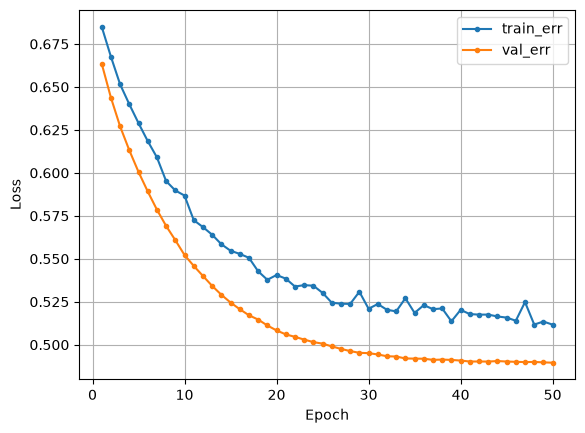

In [18]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [19]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(pred.cpu().numpy()[:5])

[[0.24512583]
 [0.20639756]
 [0.20390557]
 [0.2317418 ]
 [0.19366823]]


In [21]:
pred = np.where(pred.cpu().numpy() > .5, 1, 0)  # where : 살았는지 죽었는지 확인
print(pred[:5])

[[0]
 [0]
 [0]
 [0]
 [0]]


In [23]:
# 성능평가

print(confusion_matrix(y_val_ts.numpy(), pred))

[[112  19]
 [ 24  59]]


In [24]:
# 정확도 찍어보기

print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.82      0.85      0.84       131
         1.0       0.76      0.71      0.73        83

    accuracy                           0.80       214
   macro avg       0.79      0.78      0.79       214
weighted avg       0.80      0.80      0.80       214



In [25]:
# 이진 분류 : 은닉층 추가

# 모델링에서 불필요한 열 제거
data = data.drop(['PassengerId', 'Name'], axis = 1)


# x, y분할
target = 'Survived'
x = data.drop(target, axis =1)
y = data.loc[:, target]


# 가변수화
x = pd.get_dummies(x, columns = ['Pclass', 'Sex', 'Embarked'], drop_first = True)


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [34]:
# 모델 구조 새로 만들기 : 은닉층 추가

n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential(nn.Linear(n_feature, 50),
            nn.ReLU(),
            nn.Linear(50, 5), # 신경망 추가할 때 (깊어지게)
            nn.ReLU(),
            nn.Linear(5, 1),
            nn.Sigmoid()
            ).to(device)


loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)

In [35]:
model

Sequential(
  (0): Linear(in_features=7, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
  (5): Sigmoid()
)

In [36]:
# 학습 돌려 보기

tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 0.671171, val loss : 0.639608
Epoch 2, train loss : 0.605840, val loss : 0.577359
Epoch 3, train loss : 0.527922, val loss : 0.527479
Epoch 4, train loss : 0.495695, val loss : 0.519856
Epoch 5, train loss : 0.488024, val loss : 0.498609
Epoch 6, train loss : 0.477278, val loss : 0.490670
Epoch 7, train loss : 0.468060, val loss : 0.485987
Epoch 8, train loss : 0.466536, val loss : 0.486410
Epoch 9, train loss : 0.464069, val loss : 0.483647
Epoch 10, train loss : 0.472916, val loss : 0.478300
Epoch 11, train loss : 0.470726, val loss : 0.476902
Epoch 12, train loss : 0.466637, val loss : 0.480162
Epoch 13, train loss : 0.464053, val loss : 0.477469
Epoch 14, train loss : 0.474328, val loss : 0.482180
Epoch 15, train loss : 0.458984, val loss : 0.478585
Epoch 16, train loss : 0.468500, val loss : 0.479114
Epoch 17, train loss : 0.461033, val loss : 0.473012
Epoch 18, train loss : 0.453535, val loss : 0.478526
Epoch 19, train loss : 0.458271, val loss : 0.474110
Ep

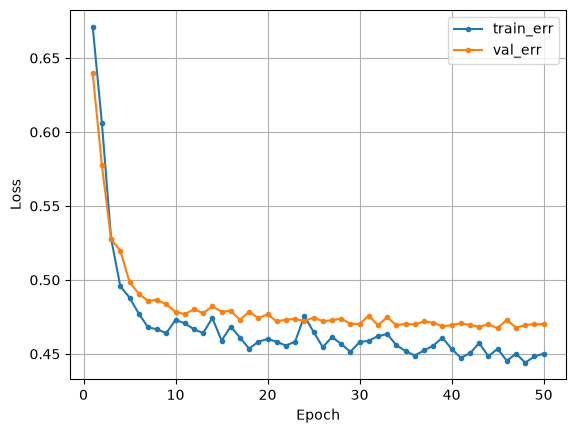

In [37]:
# 그래프 그려보기

dl_learning_curve(tr_loss_list, val_loss_list)

In [39]:
##### [실습] 이진분류 : 직원 이직 예측 #####

In [40]:
# 직원 이직 예측
path = 'https://bit.ly/attri_csv'
data = pd.read_csv(path)
data.head()

,Attrition,Age,Department,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
0,0,33,Research & Development,7,3,817,3,Male,3,Married,11691,0,No,11,0,14,3,4,13
1,0,35,Research & Development,18,2,1412,3,Male,4,Single,9362,2,No,11,0,10,2,3,2
2,0,42,Research & Development,6,3,1911,3,Male,1,Married,13348,9,No,13,1,18,3,4,13
3,0,46,Sales,2,3,1204,3,Female,1,Married,17048,8,No,23,0,28,2,3,26
4,1,22,Research & Development,4,1,593,3,Male,3,Single,3894,5,No,16,0,4,3,3,2


In [41]:
target = 'Attrition'
x = data.drop([target, 'EmployeeNumber'], axis = 1)
y = data.loc[:, target]
print(x.shape)

(1175, 17)


In [42]:
cat_cols = ['Department', 'Education', 'EnvironmentSatisfaction', 'Gender', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'WorkLifeBalance']
x = pd.get_dummies(x, columns = cat_cols, drop_first=True)
x.shape

(1175, 28)

In [43]:
# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values

In [44]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [45]:
from torchsummary import summary
n_feature = x.shape[1]
model = nn.Sequential(nn.Linear(n_feature, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
            ).to(device)
summary(model, input_size=(n_feature,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             464
              ReLU-2                   [-1, 16]               0
            Linear-3                    [-1, 8]             136
              ReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
           Sigmoid-6                    [-1, 1]               0
Total params: 609
Trainable params: 609
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [46]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [47]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 0.652877, val loss : 0.626445
Epoch 2, train loss : 0.595433, val loss : 0.541877
Epoch 3, train loss : 0.507876, val loss : 0.444605
Epoch 4, train loss : 0.454498, val loss : 0.413780
Epoch 5, train loss : 0.447628, val loss : 0.408509
Epoch 6, train loss : 0.439237, val loss : 0.404180
Epoch 7, train loss : 0.432803, val loss : 0.398007
Epoch 8, train loss : 0.425797, val loss : 0.392112
Epoch 9, train loss : 0.419296, val loss : 0.387571
Epoch 10, train loss : 0.417392, val loss : 0.380204
Epoch 11, train loss : 0.406772, val loss : 0.376588
Epoch 12, train loss : 0.401535, val loss : 0.371648
Epoch 13, train loss : 0.394602, val loss : 0.367817
Epoch 14, train loss : 0.390941, val loss : 0.363473
Epoch 15, train loss : 0.382335, val loss : 0.362217
Epoch 16, train loss : 0.376323, val loss : 0.359592
Epoch 17, train loss : 0.376497, val loss : 0.356950
Epoch 18, train loss : 0.369419, val loss : 0.356082
Epoch 19, train loss : 0.367566, val loss : 0.354882
Ep

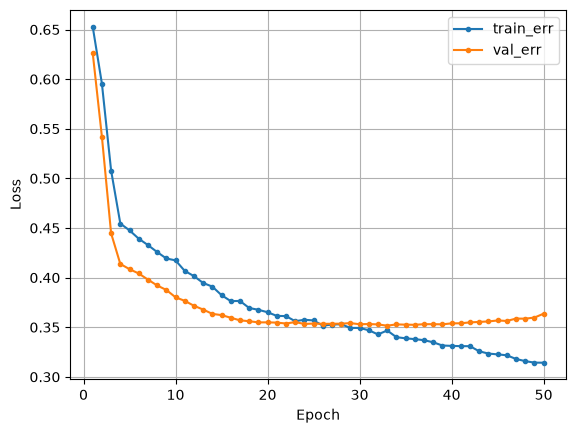

In [48]:
dl_learning_curve(tr_loss_list, val_loss_list)